# Simple ARIMA for short-term temperature forecasting

## Prepare the time series (Atlantic Canada)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [25]:
import pandas as pd

df = pd.read_csv("../Yashaswi/temp_clean.csv", 
                    dtype={"Climate ID": "string"},
                    low_memory=False
)
stations = pd.read_csv("../Yashaswi/stations_with_municipality_and_province.csv")

df["Date/Time"] = pd.to_datetime(df["Date/Time"])
df["Year"]  = df["Date/Time"].dt.year
df["Month"] = df["Date/Time"].dt.month
df["Day"]   = df["Date/Time"].dt.day

df = df.rename(columns={"Climate ID": "station_id"})
stations = stations.rename(columns={"Station ID": "station_id"})
df = df.merge(
    stations,
    on="station_id",
    how="left"
)
df.head()

,temp_Index,station_id,Date/Time,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Year,Month,Day,Latitude,Longitude,CSDUID,CSDNAME,Province
0,1000,8204020,2021-09-11,18.7,8.7,13.7,4.3,0.0,2021,9,11,44.83,-64.51,1206009,Chester,Nova Scotia
1,1001,8204020,2021-09-12,22.4,9.8,16.1,1.9,0.0,2021,9,12,44.83,-64.51,1206009,Chester,Nova Scotia
2,1002,8204020,2021-09-13,20.8,11.0,15.9,2.1,0.0,2021,9,13,44.83,-64.51,1206009,Chester,Nova Scotia
3,1003,8204020,2021-09-14,17.2,6.9,12.1,5.9,0.0,2021,9,14,44.83,-64.51,1206009,Chester,Nova Scotia
4,1004,8204020,2021-09-15,20.2,5.7,13.0,5.0,0.0,2021,9,15,44.83,-64.51,1206009,Chester,Nova Scotia


In [27]:
# Clean Province strings
df["Province"] = df["Province"].str.strip()

In [28]:
atlantic_provinces = [
    "Nova Scotia",
    "New Brunswick",
    "Newfoundland and Labrador",
    "Prince Edward Island"
]

df_atlantic = df[df["Province"].isin(atlantic_provinces)].copy()

In [29]:
df_atlantic["Province"].value_counts()

Province
Newfoundland and Labrador    315381
Nova Scotia                  287110
New Brunswick                168893
Prince Edward Island          61805
Name: count, dtype: int64

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 833189 entries, 0 to 833188
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   temp_Index          833189 non-null  int64         
 1   station_id          833189 non-null  object        
 2   Date/Time           833189 non-null  datetime64[us]
 3   Max Temp (°C)       828481 non-null  float64       
 4   Min Temp (°C)       831117 non-null  float64       
 5   Mean Temp (°C)      833189 non-null  float64       
 6   Heat Deg Days (°C)  826411 non-null  float64       
 7   Cool Deg Days (°C)  826411 non-null  float64       
 8   Year                833189 non-null  int32         
 9   Month               833189 non-null  int32         
 10  Day                 833189 non-null  int32         
 11  Latitude            833189 non-null  float64       
 12  Longitude           833189 non-null  float64       
 13  CSDUID              833189 non-null  int

In [33]:
BASELINE_START = 1990
BASELINE_END   = 2026

df_baseline = df[
    (df["Year"] >= BASELINE_START) &
    (df["Year"] <= BASELINE_END)
]
df_baseline.head(3)

,temp_Index,station_id,Date/Time,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Year,Month,Day,Latitude,Longitude,CSDUID,CSDNAME,Province
0,1000,8204020,2021-09-11,18.7,8.7,13.7,4.3,0.0,2021,9,11,44.83,-64.51,1206009,Chester,Nova Scotia
1,1001,8204020,2021-09-12,22.4,9.8,16.1,1.9,0.0,2021,9,12,44.83,-64.51,1206009,Chester,Nova Scotia
2,1002,8204020,2021-09-13,20.8,11.0,15.9,2.1,0.0,2021,9,13,44.83,-64.51,1206009,Chester,Nova Scotia


In [34]:
baseline = (
    df_baseline
    .groupby(["station_id", "Month", "Day"])["Mean Temp (°C)"]
    .mean()
    .reset_index(name="Baseline Mean Temp (°C)")
)

In [35]:

# Drop existing baseline/anomaly columns if they exist
df = df.drop(
    columns=["Baseline Mean Temp (°C)", "Temp Anomaly (°C)"],
    errors="ignore"
)

df = df.merge(
    baseline,
    on=["station_id", "Month", "Day"],
    how="left"
)

In [36]:
df["Temp Anomaly (°C)"] = (
    df["Mean Temp (°C)"] - df["Baseline Mean Temp (°C)"]
)

In [37]:
df["Temp Anomaly (°C)"].describe()

count    8.331890e+05
mean     2.728957e-18
std      3.760546e+00
min     -2.960000e+01
25%     -2.331250e+00
50%     -6.818182e-02
75%      2.290000e+00
max      2.079130e+01
Name: Temp Anomaly (°C), dtype: float64

In [39]:
atlantic_provinces = [
    "Nova Scotia",
    "New Brunswick",
    "Newfoundland and Labrador",
    "Prince Edward Island"
]

df_atlantic = df[df["Province"].isin(atlantic_provinces)].copy()
df_atlantic["Province"].value_counts()

Province
Newfoundland and Labrador    315381
Nova Scotia                  287110
New Brunswick                168893
Prince Edward Island          61805
Name: count, dtype: int64

# Atlantic annual anomaly time series

In [41]:
atlantic_annual_anomaly = (
    df_atlantic
    .groupby("Year")["Temp Anomaly (°C)"]
    .mean()
    .reset_index()
)

In [43]:
atlantic_annual_anomaly.head(3)

,Year,Temp Anomaly (°C)
0,1995,-1.052844
1,1996,-0.417509
2,1997,-1.479432


In [44]:
len(atlantic_annual_anomaly)

32

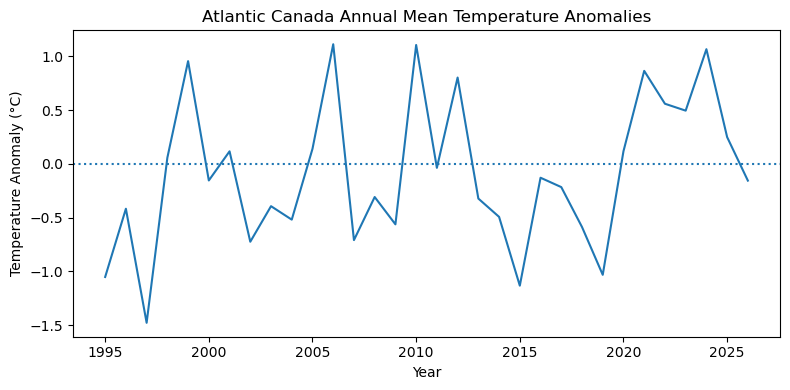

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(
    atlantic_annual_anomaly["Year"],
    atlantic_annual_anomaly["Temp Anomaly (°C)"]
)
plt.axhline(0, linestyle=":")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Atlantic Canada Annual Mean Temperature Anomalies")
plt.tight_layout()
plt.show()

In [46]:
ts = atlantic_annual_anomaly.set_index("Year")["Temp Anomaly (°C)"]

#  Step 5 — Prepare the time series for ARIMA
- ARIMA requires a 1‑D time series with a time index.

In [47]:
ts = (
    atlantic_annual_anomaly
    .set_index("Year")["Temp Anomaly (°C)"]
    .sort_index()
)

In [48]:


len(ts)

32

In [51]:
ts.info()

<class 'pandas.Series'>
RangeIndex: 32 entries, 1995 to 2026
Series name: Temp Anomaly (°C)
Non-Null Count  Dtype  
--------------  -----  
32 non-null     float64
dtypes: float64(1)
memory usage: 388.0 bytes


## How to interpret this

Clear upward tendency → non‑stationary
Year‑to‑year variability → expected
✅ Differencing will be required → ARIMA(d=1)

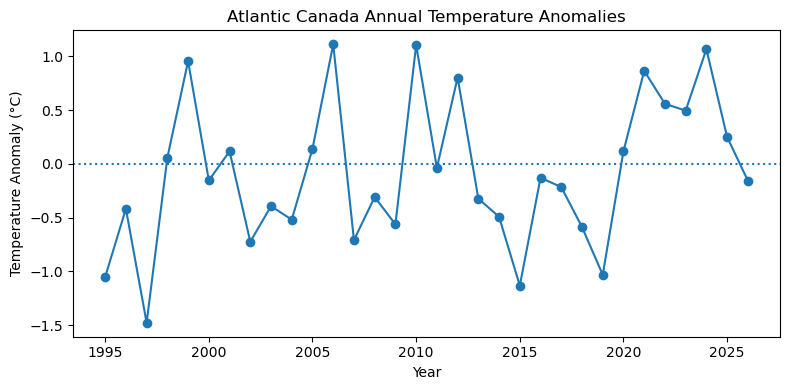

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(ts.index, ts.values, marker="o")
plt.axhline(0, linestyle=":")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Atlantic Canada Annual Temperature Anomalies")
plt.tight_layout()
plt.show()

## Step 7 — Fit a simple ARIMA model
Recommended climate‑safe starting model
ARIMA(1,1,1)
(robust, avoids overfitting, standard for short series)

In [54]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts, order=(1, 1, 1))
model_fit = model.fit()

In [55]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      Temp Anomaly (°C)   No. Observations:                   32
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -33.389
Date:                Wed, 06 May 2026   AIC                             72.777
Time:                        21:05:34   BIC                             77.079
Sample:                             0   HQIC                            74.180
                                 - 32                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2393      0.240      0.999      0.318      -0.230       0.709
ma.L1         -0.9614      0.325     -2.958      0.003      -1.598      -0.324
sigma2         0.4726      0.162      2.926      0.003       0.156       0.789
===================================================================================
Ljung-Box (L1) (Q):                   0.24   Jarque-Bera (JB):                 1.54
Prob(Q):                              0.62   Prob(JB):                         0.46
Heteroskedasticity (H):               0.78   Skew:                             0.26
Prob(H) (two-sided):                  0.71   Kurtosis:                         2.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Step 8 — Short‑term forecast (5 years)

In [56]:
forecast_years = 5

forecast = model_fit.get_forecast(steps=forecast_years)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

## Step 9 — Plot observed + forecast

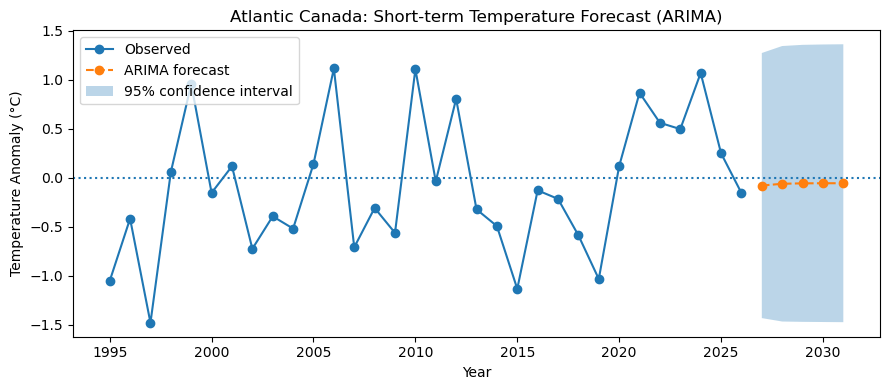

In [57]:
plt.figure(figsize=(9,4))

# Observed
plt.plot(ts.index, ts.values, label="Observed", marker="o")

# Forecast
plt.plot(
    forecast_mean.index,
    forecast_mean.values,
    linestyle="--",
    marker="o",
    label="ARIMA forecast"
)

# Confidence interval
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3,
    label="95% confidence interval"
)

plt.axhline(0, linestyle=":")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Atlantic Canada: Short‑term Temperature Forecast (ARIMA)")
plt.legend()
plt.tight_layout()
plt.show()

### “Short‑term statistical forecasting was performed using an ARIMA(1,1,1) model applied to annual mean temperature anomalies. The forecast suggests persistence of recent positive anomaly conditions over the next several years, with substantial interannual variability. The ARIMA results complement, rather than replace, the linear trend analysis, which captures the longer‑term forced warming signal across Atlantic Canada.”